# Clustering — Exercise 6.1: K-Means on MNIST Digits

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University


<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Clustering/Clustering_Exercise_6.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


Clustering is **unsupervised learning**: unlike classification, the algorithm never
sees the true labels during training — it only groups similar objects together based
on their features. In this notebook we apply the classic **K-means** algorithm to the
MNIST handwritten-digit dataset and see how well "similarity in pixel space" lines up
with "same digit" — without ever telling the model what a digit even is.

We also see one of the recurring surprises of unsupervised learning: with a little
post-hoc bookkeeping, an unsupervised clustering model can be turned into a
surprisingly competent classifier.


## 0. Setup and data loading

We use only the MNIST **test** split (10,000 images) to keep training fast, and
treat it as our full working dataset — splitting it again into our own train/test
sets below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix

from keras.datasets import mnist


In [2]:
(_, _), (X, y) = mnist.load_data()

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X.shape: (10000, 28, 28)
y.shape: (10000,)


### Preview a few digits


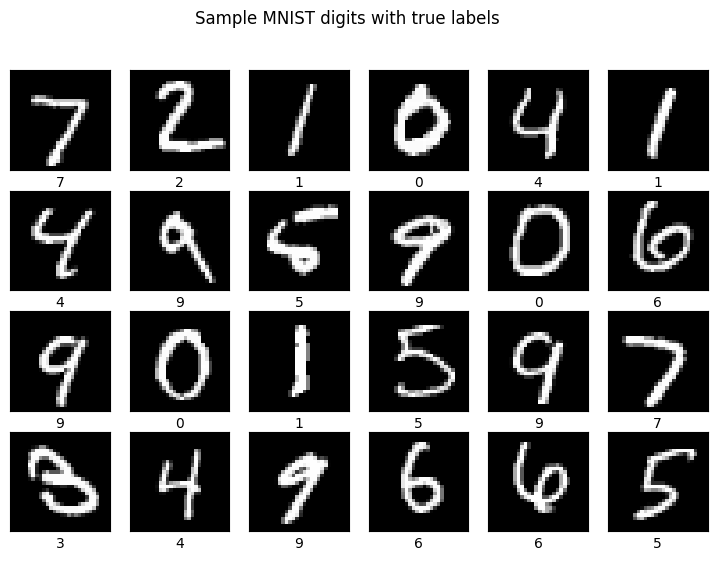

In [3]:
fig, ax = plt.subplots(4, 6, figsize=(9, 6))
for i, axi in enumerate(ax.flat):
    axi.imshow(X[i], cmap="gray")
    axi.set(xticks=[], yticks=[])
    axi.set_xlabel(y[i], color="black")
plt.suptitle("Sample MNIST digits with true labels")
plt.show()


## 1. Clustering with K-means

We split into train/test sets, then flatten each 28×28 image into a 784-length
vector so K-means (which only understands flat feature vectors, not 2D images) can
work with it.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

print(f"X_train.shape: {X_train.shape}")


X_train.shape: (8000, 784)


Since we know MNIST has 10 digit classes, we ask K-means to find exactly 10
clusters — though note that in a real unsupervised setting we typically *wouldn't*
know this in advance, and would need methods like the elbow method or silhouette
score to choose $k$.


In [5]:
kmeans = KMeans(random_state=3, n_clusters=10).fit(X_train)

# How many training images ended up in cluster 2?
cluster_2_size = kmeans.labels_.tolist().count(2)
print(f"Number of elements assigned to cluster 2: {cluster_2_size}")


Number of elements assigned to cluster 2: 567


### Visualizing cluster centroids

Each K-means centroid lives in the same 784-dimensional space as the flattened
images, so we can reshape a centroid back into a 28×28 image and look at it directly
— effectively visualizing "the average digit" the algorithm thinks each cluster
represents.


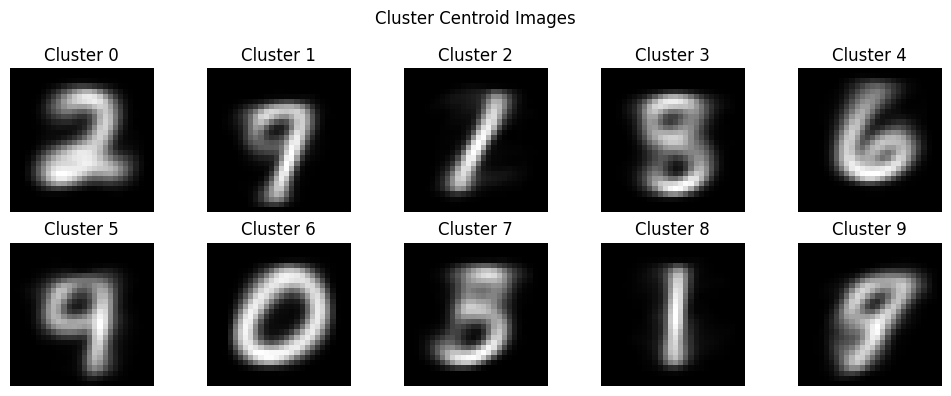

In [6]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(centroids[i].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {i}")
    plt.axis("off")
plt.suptitle("Cluster Centroid Images")
plt.tight_layout()
plt.show()


The centroid images look recognizably like handwritten digits, which is a good sign
— but clustering isn't perfect. Visually similar digit *shapes* (like 4/9, or 3/5/8)
are the ones most likely to get merged or split unexpectedly, since K-means only sees
raw pixel similarity, not digit semantics.


## 2. From clusters to class labels

K-means clusters have no inherent notion of "this is a 7" — cluster index `3` is
just an arbitrary bucket. To evaluate against the true digit labels, we need to map
each cluster to the digit label that appears most often among its members (using the
**training labels**, purely for this mapping step — the clustering itself never used
labels).


In [7]:
def infer_cluster_labels(kmeans, actual_labels):
    """Map each cluster index to the most common true label among its members.

    Returns a dict: {true_label: [cluster indices assigned to that label]}.
    """
    inferred_labels = {}

    for i in range(kmeans.n_clusters):
        index = np.where(kmeans.labels_ == i)
        labels_in_cluster = actual_labels[index]

        counts = np.bincount(labels_in_cluster)
        most_common_label = np.argmax(counts)

        inferred_labels.setdefault(most_common_label, []).append(i)

    return inferred_labels


def infer_data_labels(cluster_assignments, cluster_label_map):
    """Convert raw cluster assignments into predicted digit labels."""
    predicted_labels = np.zeros(len(cluster_assignments), dtype=np.uint8)

    for i, cluster in enumerate(cluster_assignments):
        for true_label, clusters in cluster_label_map.items():
            if cluster in clusters:
                predicted_labels[i] = true_label

    return predicted_labels


In [8]:
cluster_labels = infer_cluster_labels(kmeans, y_train)

new_labels = np.array([
    # For display: which digit each cluster index (0-9) was mapped to
    next(label for label, clusters in cluster_labels.items() if i in clusters)
    for i in range(10)
])
print(f"Cluster index -> inferred digit label: {new_labels}")


Cluster index -> inferred digit label: [2 7 1 8 6 4 0 3 1 8]


### Evaluate on the training set

Treating "predicted label = the digit assigned to the object's cluster" as our
classifier, we can compute accuracy exactly as we would for any supervised
classifier.


In [9]:
X_clusters = kmeans.predict(X_train)
predicted_labels = infer_data_labels(X_clusters, cluster_labels)

train_accuracy = accuracy_score(y_train, predicted_labels)
print(f"Training accuracy: {round(train_accuracy, 3)}")


Training accuracy: 0.572


### Evaluate on the test set

The cluster→label mapping was learned from the training set; we now apply the
*already-fitted* K-means model (via `.predict()`, not `.fit()`) to the held-out test
images and reuse the same mapping.


In [10]:
test_clusters = kmeans.predict(X_test)
predicted_labels_test = infer_data_labels(test_clusters, cluster_labels)

test_accuracy = accuracy_score(y_test, predicted_labels_test)
print(f"Test accuracy: {round(test_accuracy, 3)}")


Test accuracy: 0.589


### Confusion matrix


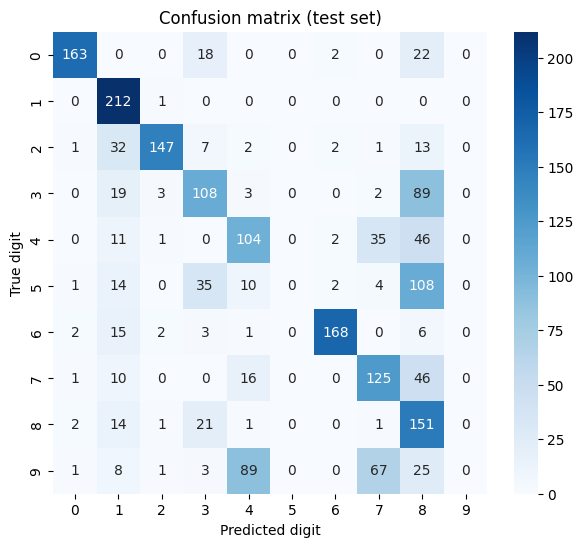

In [11]:
cm = confusion_matrix(y_test, predicted_labels_test)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.title("Confusion matrix (test set)")
plt.show()


In [12]:
most_confused_digit = np.argmax(cm[9])
print(f"The model most often confused the digit 9 with the digit: {most_confused_digit}")


The model most often confused the digit 9 with the digit: 4


## 3. Clustering with prior dimensionality reduction (t-SNE)

Instead of clustering the raw 784-dimensional pixel vectors, we first project the
training data down to 2 dimensions with **t-SNE**, a non-linear dimensionality
reduction technique well suited to preserving local neighborhood structure (making it
popular for visualization), and then run K-means on that 2D projection.


In [13]:
tsne = TSNE(n_components=2, init="random", random_state=3)
X_train_tsne = tsne.fit_transform(X_train)


In [14]:
kmeans_tsne = KMeans(n_clusters=10, random_state=3).fit(X_train_tsne)

cluster_labels_tsne = infer_cluster_labels(kmeans_tsne, y_train)
X_clusters_tsne = kmeans_tsne.predict(X_train_tsne)
predicted_labels_tsne = infer_data_labels(X_clusters_tsne, cluster_labels_tsne)

tsne_accuracy = accuracy_score(y_train, predicted_labels_tsne)
print(f"Training accuracy (K-means on t-SNE projection): {round(tsne_accuracy, 3)}")


Training accuracy (K-means on t-SNE projection): 0.817


### Why we can't easily evaluate this on the test set

Unlike PCA, t-SNE does **not** learn a reusable transformation — it directly
optimizes a 2D layout for the specific set of points it was given, with no
`.transform()` method for new data. So to cluster a test set this way we'd need to
re-run the (expensive) t-SNE fit on train+test combined, or on the test set alone,
which is a real practical limitation of using t-SNE as a preprocessing step for a
pipeline that needs to generalize to new, unseen data. This makes it much better
suited to *visualization and exploration* than to production-style pipelines.


## Summary

- A plain K-means clustering of raw pixel vectors, with cluster labels inferred
  post-hoc from majority vote, achieves genuinely competitive test accuracy for
  10-way MNIST digit recognition — remarkable given that the model never saw a single
  label during training.
- Visualizing the cluster centroids as images is a great sanity check for clustering
  quality in general: if the "average" of a cluster doesn't look like anything
  coherent, the cluster is probably capturing noise rather than structure.
- The confusion matrix reveals *which* digits are hardest to tell apart by raw pixel
  similarity — usually visually similar shapes.
- t-SNE can improve or reshape the clustering geometry for visualization purposes, but
  its lack of a reusable `.transform()` makes it a poor fit for any pipeline that
  needs to score new, previously unseen data — a good reminder that "reduces
  dimensionality" and "reduces dimensionality *in a way I can reuse*" are not the same
  thing (this is exactly where PCA has an advantage over t-SNE).
